In [2]:
# --- 1. Kütüphaneler ve Drive Bağlantısı ---
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor
from sklearn.svm import SVR

# Google Drive Bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# --- Kişisel Bilgiler ve Yollar ---
USER_NAME = "abdumajid"
BASE_PATH = "/content/drive/MyDrive/veri-madenciligi-projesi/Bitcoin Final Projesi/Bitcoin Price Prediction Project"
DATA_PATH = os.path.join(BASE_PATH, "data", "merged_with_lags.csv")

# Çıktı Klasörleri
RESULTS_DIR = os.path.join(BASE_PATH, "results")
MODELS_DIR = os.path.join(BASE_PATH, "models", f"models_advanced_{USER_NAME}")
PLOTS_DIR = os.path.join(BASE_PATH, "plots", f"plots_advanced_{USER_NAME}")

# Klasörleri oluştur
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(" Kurulum tamamlandı. Drive bağlandı ve klasörler hazır.")
print(f"📂 Kayıt Yeri: {BASE_PATH}")

Mounted at /content/drive
 Kurulum tamamlandı. Drive bağlandı ve klasörler hazır.
📂 Kayıt Yeri: /content/drive/MyDrive/veri-madenciligi-projesi/Bitcoin Final Projesi/Bitcoin Price Prediction Project


In [5]:
# --- 2. Veri Yükleme ve Hazırlık ---
print("⏳ Veri yükleniyor...")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"HATA: Veri dosyası bulunamadı! Yol: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# Tarih formatı ve sıralama
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Hedef değişkenler (Bunları X'ten çıkaracağız)
targets = ["Target_1d", "Target_7d", "Target_30d", "Target_365d"]

# X (Feature) oluşturma
X = df.drop(columns=["Date"] + targets)
X = X.select_dtypes(include=[np.number]) # Sadece sayısal veriler

# Temizlik (Sonsuz değerler ve NaN temizliği)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.ffill().bfill()

print(f"✅ Veri hazırlandı.")
print(f"📊 Veri Boyutu: {df.shape}")
print(f"🔢 Özellik Sayısı (Features): {X.shape[1]}")
print("Örnek Veri (İlk 3 satır):")
display(X.head(3))

⏳ Veri yükleniyor...
✅ Veri hazırlandı.
📊 Veri Boyutu: (3338, 117)
🔢 Özellik Sayısı (Features): 112
Örnek Veri (İlk 3 satır):


,FEDFUNDS,ECBDFR,CPI,UNRATE,IVV,GSPC,EURUSDX,DXY,PAYEMS,WALCL,...,GCF_lag7,GCF_lag30,GCF_lag90,GCF_lag365,GDP_lag1,GDP_lag3,GDP_lag7,GDP_lag30,GDP_lag90,GDP_lag365
0,0.14,-0.2,23.511166,5.0,167.513916,3.239860e+09,0.0,991.849976,142275.0,4478213.0,...,138.0,908.0,168.0,10.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228
1,0.14,-0.2,23.466616,5.0,169.016098,3.630680e+09,0.0,982.549988,142275.0,4487809.0,...,150.0,399.0,130.0,10.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228
2,0.14,-0.2,23.573530,5.0,168.588120,4.183790e+09,0.0,991.849976,142275.0,4487809.0,...,56.0,475.0,142.0,10.0,18401.626,18401.626,18401.626,18401.626,18279.784,17804.228


In [6]:
# --- 3. Model Konfigürasyonu ---
# Cross-Validation ayarı (Zaman serisi olduğu için TimeSeriesSplit kullanıyoruz)
tscv = TimeSeriesSplit(n_splits=3)

models_config = {
    "XGBoost": {
        "model": XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 6],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0]
        }
    },
    "SVR": {
        # SVR için veriyi ölçeklendirmek (Scaling) zorunludur
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR())
        ]),
        "params": {
            "svr__kernel": ["rbf"],
            "svr__C": [1, 10, 50],
            "svr__gamma": ["scale", 0.1],
            "svr__epsilon": [0.1, 0.01]
        }
    }
}

print("✅ Modeller ve parametreler tanımlandı.")

✅ Modeller ve parametreler tanımlandı.


In [7]:
# --- 4. Eğitim, Tahmin ve Kaydetme Döngüsü ---
results = [] # Sonuçları burada toplayacağız

print("🚀 Eğitim başlıyor... Bu işlem biraz zaman alabilir.")

# Train/Test ayrımı için indeks (İlk %80 Eğitim, Son %20 Test)
split_idx = int(len(df) * 0.8)
dates_test = df["Date"].iloc[split_idx:].reset_index(drop=True)

# Feature setlerini ayır
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

for target in targets:
    print(f"\n🎯 Hedef: {target} işleniyor...")

    # Target verisini hazırla
    y = df[target].ffill().bfill()
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    for model_name, config in models_config.items():
        print(f"   ⚙️  Model: {model_name} eğitiliyor (Tuning yapılıyor)...")

        # SVR yavaş olduğu için deneme sayısını (n_iter) düşük tutuyoruz
        n_iter_search = 10 if model_name == "XGBoost" else 5

        # Hyperparameter Tuning
        search = RandomizedSearchCV(
            estimator=config["model"],
            param_distributions=config["params"],
            n_iter=n_iter_search,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            random_state=42,
            verbose=0
        )

        search.fit(X_train, y_train)

        # En iyi model ile tahmin
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        # Metrik Hesaplama
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        try:
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100
        except:
            mape = np.nan

        print(f"      👉 Sonuç: RMSE={rmse:.2f}, R2={r2:.3f}")

        # --- GRAFİK ÇİZİMİ ---
        plt.figure(figsize=(10, 5))
        plt.plot(dates_test, y_test, label='Gerçek (Real)', color='blue', alpha=0.6)
        plt.plot(dates_test, y_pred, label=f'Tahmin ({model_name})', color='red', alpha=0.7, linestyle='--')
        plt.title(f"{target} - {model_name} (R2: {r2:.2f})")
        plt.legend()
        plot_path = os.path.join(PLOTS_DIR, f"plot_{model_name}_{target}.png")
        plt.savefig(plot_path)
        plt.close()

        # --- MODEL KAYDETME ---
        model_path = os.path.join(MODELS_DIR, f"{model_name}_{target}.joblib")
        joblib.dump(best_model, model_path)

        # Sonuçları listeye ekle
        results.append({
            "Target": target,
            "Model": model_name,
            "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape,
            "Best_Params": str(search.best_params_)
        })

        # --- BONUS: Feature Importance (Sadece XGBoost) ---
        if model_name == "XGBoost":
            plt.figure(figsize=(8, 6))
            importances = best_model.feature_importances_
            feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)
            feat_imp.plot(kind='barh', title=f'Feature Importance - {target}')
            plt.savefig(os.path.join(PLOTS_DIR, f"feature_imp_XGBoost_{target}.png"))
            plt.close()

print("\n✅ Tüm modeller eğitildi ve kaydedildi.")

🚀 Eğitim başlıyor... Bu işlem biraz zaman alabilir.

🎯 Hedef: Target_1d işleniyor...
   ⚙️  Model: XGBoost eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=6982.27, R2=0.838
   ⚙️  Model: SVR eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=36440.41, R2=-3.425

🎯 Hedef: Target_7d işleniyor...
   ⚙️  Model: XGBoost eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=11927.14, R2=0.530
   ⚙️  Model: SVR eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=36886.60, R2=-3.491

🎯 Hedef: Target_30d işleniyor...
   ⚙️  Model: XGBoost eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=23172.26, R2=-0.470
   ⚙️  Model: SVR eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=39835.32, R2=-3.344

🎯 Hedef: Target_365d işleniyor...
   ⚙️  Model: XGBoost eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=53441.54, R2=-4.477
   ⚙️  Model: SVR eğitiliyor (Tuning yapılıyor)...
      👉 Sonuç: RMSE=69481.67, R2=-8.257

✅ Tüm modeller eğitildi ve kaydedildi.


In [8]:
# --- 5. Raporlama ---
results_df = pd.DataFrame(results)

# CSV Olarak Kaydet
csv_path = os.path.join(RESULTS_DIR, f"results_advanced_{USER_NAME}.csv")
results_df.to_csv(csv_path, index=False)

print("\n" + "="*50)
print("🏁 FİNAL RAPORU")
print("="*50)
print(f"💾 Sonuç CSV dosyası: {csv_path}")
print(f"💾 Modeller klasörü: {MODELS_DIR}")
print(f"💾 Grafikler klasörü: {PLOTS_DIR}")
print("\n--- ÖZET TABLO ---")
display(results_df)


🏁 FİNAL RAPORU
💾 Sonuç CSV dosyası: /content/drive/MyDrive/veri-madenciligi-projesi/Bitcoin Final Projesi/Bitcoin Price Prediction Project/results/results_advanced_abdumajid.csv
💾 Modeller klasörü: /content/drive/MyDrive/veri-madenciligi-projesi/Bitcoin Final Projesi/Bitcoin Price Prediction Project/models/models_advanced_abdumajid
💾 Grafikler klasörü: /content/drive/MyDrive/veri-madenciligi-projesi/Bitcoin Final Projesi/Bitcoin Price Prediction Project/plots/plots_advanced_abdumajid

--- ÖZET TABLO ---


,Target,Model,RMSE,MAE,R2,MAPE,Best_Params
0,Target_1d,XGBoost,6982.269531,5303.070631,0.837530,10.338070,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
1,Target_1d,SVR,36440.407795,31953.358421,-3.425347,67.993504,"{'svr__kernel': 'rbf', 'svr__gamma': 'scale', ..."
2,Target_7d,XGBoost,11927.139074,10561.696994,0.530474,23.601316,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
3,Target_7d,SVR,36886.601509,32418.438298,-3.490806,68.330119,"{'svr__kernel': 'rbf', 'svr__gamma': 'scale', ..."
4,Target_30d,XGBoost,23172.255291,18006.109162,-0.469867,33.171749,"{'subsample': 0.7, 'n_estimators': 100, 'max_d..."
5,Target_30d,SVR,39835.319617,34853.118322,-3.343884,69.687479,"{'svr__kernel': 'rbf', 'svr__gamma': 'scale', ..."
6,Target_365d,XGBoost,53441.540157,48283.413905,-4.476569,54.235948,"{'subsample': 0.7, 'n_estimators': 100, 'max_d..."
7,Target_365d,SVR,69481.673562,65540.721277,-8.257445,76.610799,"{'svr__kernel': 'rbf', 'svr__gamma': 'scale', ..."


In [9]:
# --- 6.1. Hazırlık ve Kütüphaneler ---
print("⚙️ Analiz ortamı hazırlanıyor...")

# SHAP kütüphanesi yüklü değilse yükle
try:
    import shap
except ImportError:
    !pip install shap
    import shap

# Grafik stili ayarları
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

print("✅ Kütüphaneler hazır. Analizlere başlayabilirsin.")

⚙️ Analiz ortamı hazırlanıyor...
✅ Kütüphaneler hazır. Analizlere başlayabilirsin.


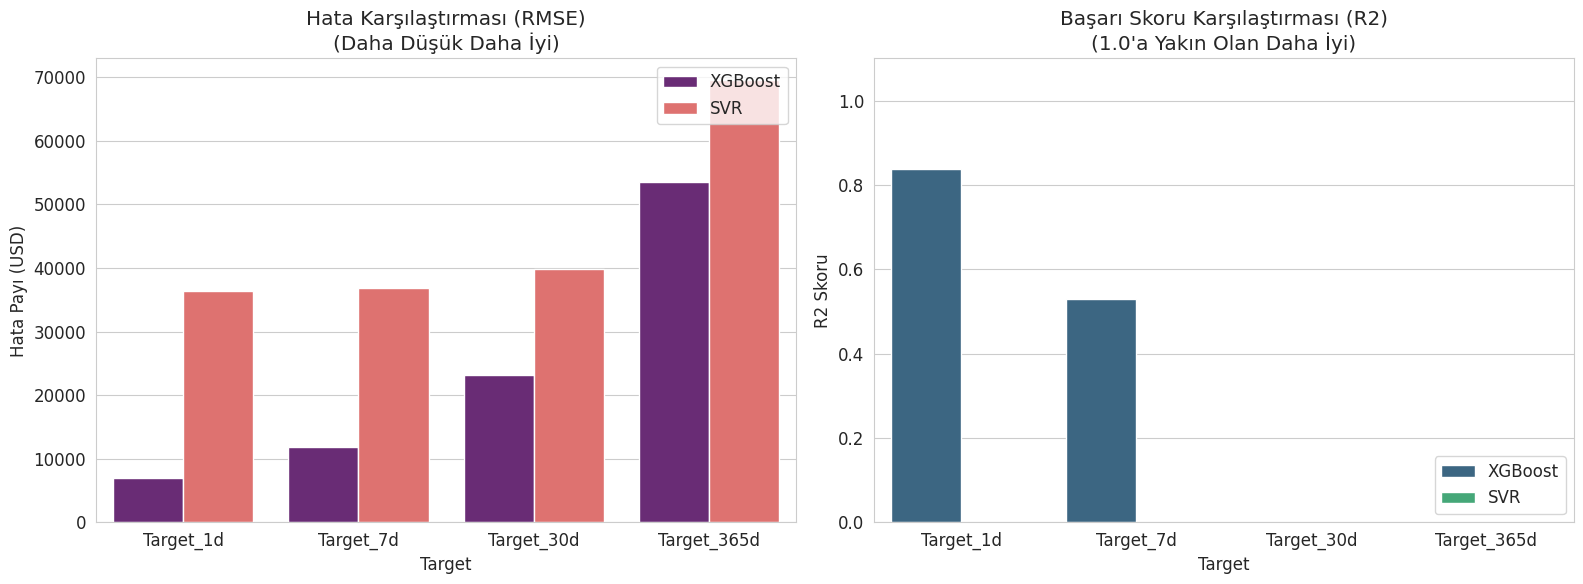

✅ Karşılaştırma grafikleri çizildi ve kaydedildi.


In [10]:
# --- 6.2. Model Performans Karşılaştırması ---
if 'results_df' in locals() and not results_df.empty:
    plt.figure(figsize=(16, 6))

    # 1. RMSE Karşılaştırması (Daha düşük çubuklar daha iyi)
    plt.subplot(1, 2, 1)
    sns.barplot(data=results_df, x='Target', y='RMSE', hue='Model', palette='magma')
    plt.title('Hata Karşılaştırması (RMSE)\n(Daha Düşük Daha İyi)')
    plt.ylabel('Hata Payı (USD)')
    plt.legend(loc='upper right')

    # 2. R2 Karşılaştırması (Daha yüksek çubuklar daha iyi)
    plt.subplot(1, 2, 2)
    sns.barplot(data=results_df, x='Target', y='R2', hue='Model', palette='viridis')
    plt.title('Başarı Skoru Karşılaştırması (R2)\n(1.0\'a Yakın Olan Daha İyi)')
    plt.ylabel('R2 Skoru')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "compare_models_metrics.png"))
    plt.show()
    print("✅ Karşılaştırma grafikleri çizildi ve kaydedildi.")
else:
    print("⚠️ HATA: 'results_df' bulunamadı. Lütfen önceki adımları (Hücre 5) çalıştırın.")

In [11]:
# --- 6.3. Tekil Model Analizi İçin Yükleme ---
# Analiz edilecek hedef ve modeli seç
target_analysis = "Target_1d"
model_analysis = "XGBoost"

print(f"🔍 '{model_analysis}' modeli ve '{target_analysis}' hedefi için veriler hazırlanıyor...")

# Kaydedilmiş modeli bul ve yükle
model_path = os.path.join(MODELS_DIR, f"{model_analysis}_{target_analysis}.joblib")

if os.path.exists(model_path):
    # Modeli yükle
    loaded_model = joblib.load(model_path)

    # Test verilerini hazırla (X_test ve y_true)
    # Not: split_idx önceki adımlardan gelmeli
    split_idx = int(len(df) * 0.8)

    X_test_curr = X.iloc[split_idx:]
    y_true = df[target_analysis].ffill().bfill().iloc[split_idx:]
    dates_curr = df["Date"].iloc[split_idx:].reset_index(drop=True)

    # Tahmin yap
    y_pred = loaded_model.predict(X_test_curr)

    # Hataları (Residuals) hesapla: Gerçek - Tahmin
    residuals = y_true - y_pred

    print("✅ Model yüklendi ve tahminler oluşturuldu.")
else:
    print(f"⚠️ HATA: Model dosyası bulunamadı: {model_path}")
    print("Lütfen eğitim (Hücre 4) aşamasının tamamlandığından emin ol.")

🔍 'XGBoost' modeli ve 'Target_1d' hedefi için veriler hazırlanıyor...
✅ Model yüklendi ve tahminler oluşturuldu. Sonraki hücreye geçebilirsin.


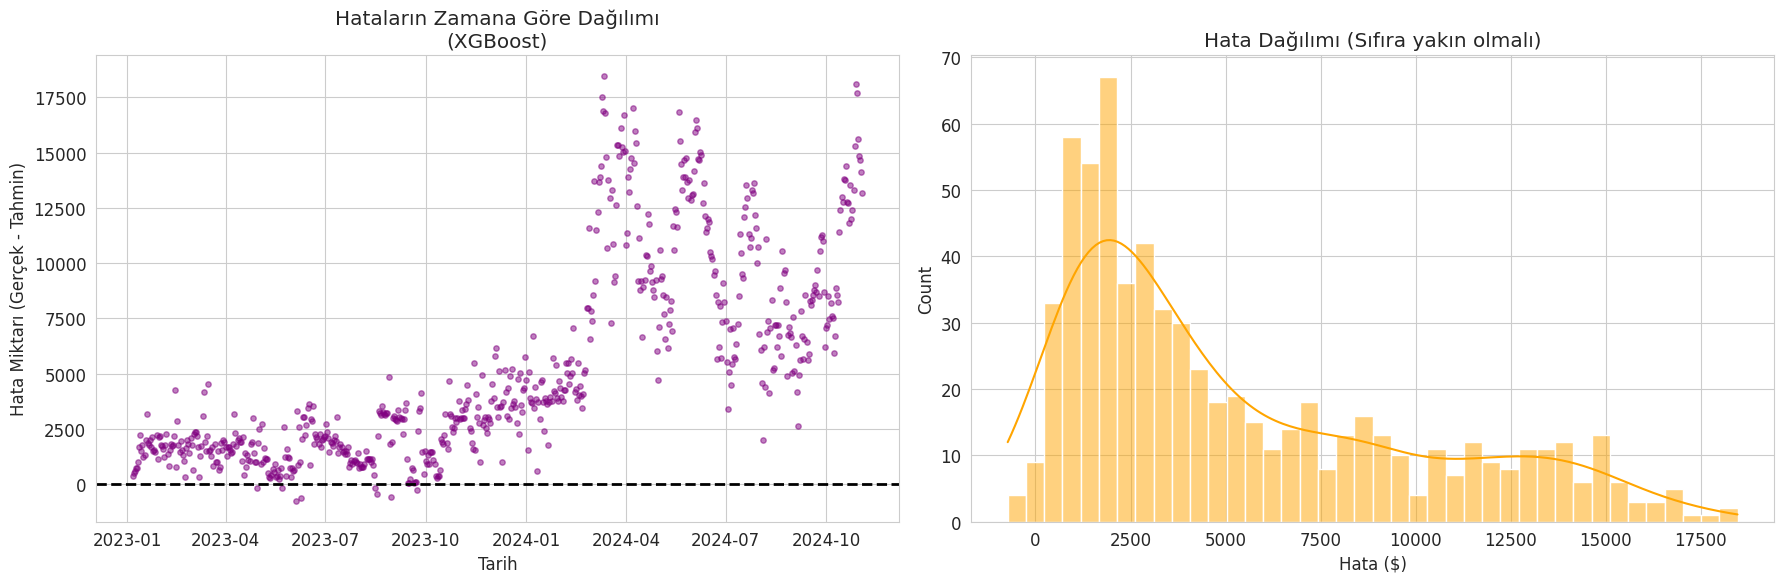

✅ Hata analiz grafikleri çizildi.


In [12]:
# --- 6.4. Hata Analizi (Residual Plots) ---
if 'residuals' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Grafik 1: Hataların Zamanla Dağılımı (Scatter)
    axes[0].scatter(dates_curr, residuals, alpha=0.5, color='purple', s=15)
    axes[0].axhline(0, color='black', linestyle='--', lw=2) # 0 çizgisi
    axes[0].set_title(f'Hataların Zamana Göre Dağılımı\n({model_analysis})')
    axes[0].set_ylabel('Hata Miktarı (Gerçek - Tahmin)')
    axes[0].set_xlabel('Tarih')

    # Grafik 2: Hata Dağılımı (Histogram)
    sns.histplot(residuals, kde=True, color='orange', bins=40, ax=axes[1])
    axes[1].set_title('Hata Dağılımı (Sıfıra yakın olmalı)')
    axes[1].set_xlabel('Hata ($)')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"residuals_analysis_{target_analysis}.png"))
    plt.show()
    print("✅ Hata analiz grafikleri çizildi.")
else:
    print("⚠️ Lütfen önce Hücre 6.3'ü çalıştırın.")

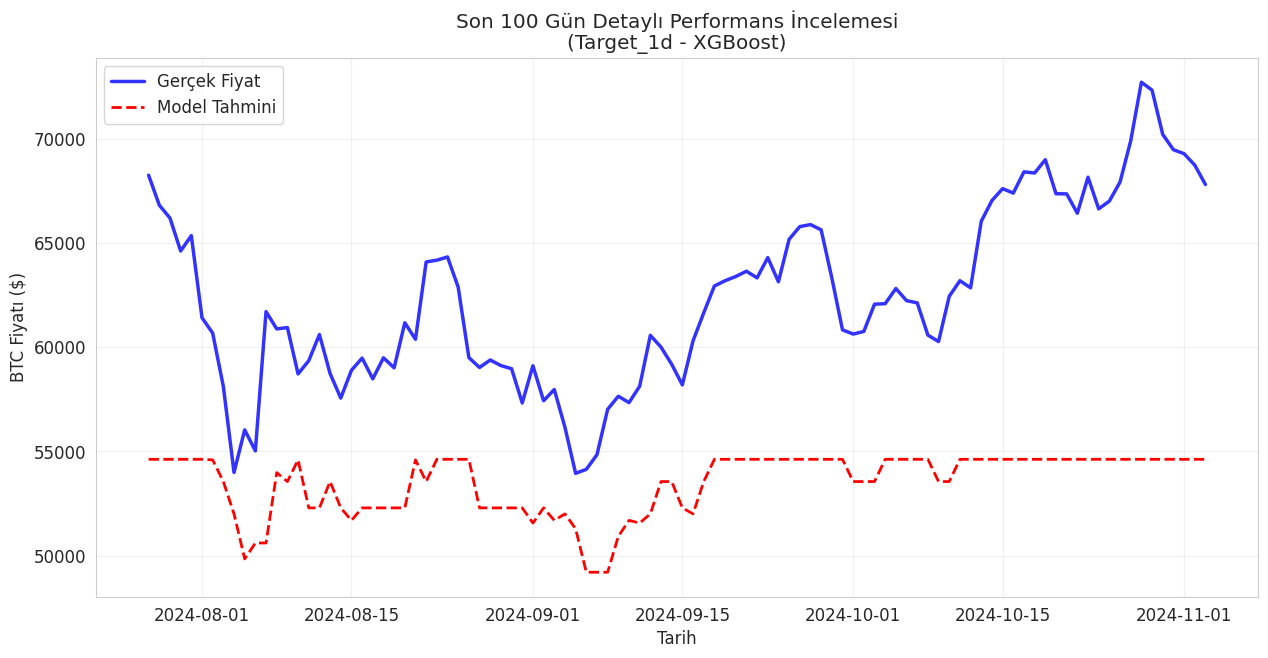

✅ Zoom-in grafiği çizildi.


In [13]:
# --- 6.5. Zoom-in (Son 100 Gün) ---
if 'y_true' in locals():
    last_n_days = 100  # Son kaç günü görmek istiyorsun?

    plt.figure(figsize=(15, 7))

    # Gerçek veriyi çiz
    plt.plot(dates_curr[-last_n_days:], y_true[-last_n_days:],
             label='Gerçek Fiyat', color='blue', linewidth=2.5, alpha=0.8)

    # Tahmini çiz
    plt.plot(dates_curr[-last_n_days:], y_pred[-last_n_days:],
             label='Model Tahmini', color='red', linestyle='--', linewidth=2)

    plt.title(f'Son {last_n_days} Gün Detaylı Performans İncelemesi\n({target_analysis} - {model_analysis})')
    plt.xlabel('Tarih')
    plt.ylabel('BTC Fiyatı ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(os.path.join(PLOTS_DIR, f"zoom_last{last_n_days}_{target_analysis}.png"))
    plt.show()
    print("✅ Zoom-in grafiği çizildi.")
else:
    print("⚠️ Lütfen önce Hücre 6.3'ü çalıştırın.")

✨ SHAP değerleri hesaplanıyor... (Biraz sürebilir)


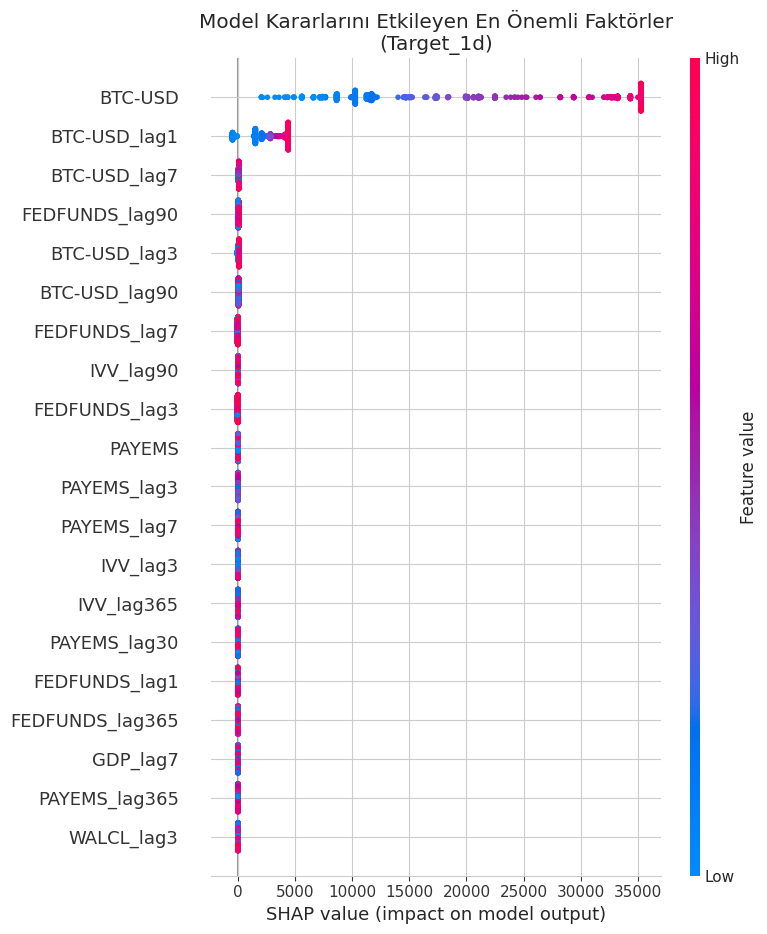

✅ SHAP analizi tamamlandı. Bu grafik hangi verilerin (lag'lerin) fiyatı etkilediğini gösterir.


In [14]:
# --- 6.6. SHAP Özellik Önemi Analizi ---
# Not: Bu analiz sadece Tree tabanlı modellerde (XGBoost, RandomForest vb.) hızlı çalışır.
if 'loaded_model' in locals() and model_analysis == "XGBoost":
    print("✨ SHAP değerleri hesaplanıyor... (Biraz sürebilir)")

    # XGBoost model nesnesini al
    # (RandomizedSearch içinden 'best_estimator_' zaten alınmıştı ama joblib direkt modeli kaydettiği için loaded_model'i kullanabiliriz)

    try:
        # Explainer oluştur
        explainer = shap.TreeExplainer(loaded_model)
        shap_values = explainer.shap_values(X_test_curr)

        # Summary Plot Çizimi
        plt.figure(figsize=(10, 8))
        plt.title(f"Model Kararlarını Etkileyen En Önemli Faktörler\n({target_analysis})")

        # Grafik oluştur (show=False diyerek matplotlib figürüne müdahale ediyoruz)
        shap.summary_plot(shap_values, X_test_curr, show=False)

        # Kaydet ve Göster
        plt.savefig(os.path.join(PLOTS_DIR, f"shap_summary_{target_analysis}.png"), bbox_inches='tight')
        plt.show()

        print("✅ SHAP analizi tamamlandı. Bu grafik hangi verilerin (lag'lerin) fiyatı etkilediğini gösterir.")

    except Exception as e:
        print(f"⚠️ SHAP analizi sırasında bir hata oluştu: {e}")
        print("Modeliniz Tree tabanlı olmayabilir veya sürüm uyumsuzluğu olabilir.")
else:
    print(f"⚠️ SHAP analizi '{model_analysis}' için bu kod bloğunda atlandı.")
    print("(SVR gibi modellerde SHAP KernelExplainer gerekir ve çok uzun sürer, final için XGBoost yeterlidir.)")